## Data Mining Project : Outlier Detection with Data Depth
Loan Rottier and Simon Simus
Data: Meteonet
Objective: Find the outliers among stations data

## Import packages

In [2]:
! pip install data-depth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 5.1 MB/s eta 0:00:00


In [3]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from depth.model import DepthEucl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from depth.model.DepthEucl import DepthEucl

## Import and preprocess data

In [ ]:
data = pd.read_csv("SE_20160101.csv", parse_dates=["date"])
data = data[["number_sta", "lat", "lon", "date", "dd", "ff", "precip", "hu", "t", "psl"]]
data = data.dropna(subset = ["dd", "ff", "precip", "hu", "t", "psl"])
data["heure"] = data["date"].dt.hour
data["minute"] = data["date"].dt.minute
data["seconde"] = data["date"].dt.second
data["heure_complete"] = pd.to_timedelta(
    data["heure"].astype(str) + ":" +
    data["minute"].astype(str) + ":" +
    data["seconde"].astype(str)
)
data

,number_sta,lat,lon,date,dd,ff,precip,hu,t,psl,heure,minute,seconde,heure_complete
4,1089001,45.98,5.33000,2016-01-01 00:00:00,0.0,0.0,0.0,95.0,279.55,102720.0,0,0,0,0 days 00:00:00
10,3060001,46.17,3.40000,2016-01-01 00:00:00,210.0,1.7,0.0,97.0,275.05,102830.0,0,0,0,0 days 00:00:00
16,4049001,44.06,5.99000,2016-01-01 00:00:00,80.0,0.8,0.0,83.0,278.75,102660.0,0,0,0,0 days 00:00:00
35,5170001,44.45,6.03000,2016-01-01 00:00:00,10.0,1.4,0.0,96.0,275.35,102760.0,0,0,0,0 days 00:00:00
42,6029001,43.56,6.95000,2016-01-01 00:00:00,10.0,1.5,0.0,79.0,282.85,102590.0,0,0,0,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111608,83137001,43.10,5.93000,2016-01-01 23:54:00,80.0,6.8,0.0,86.0,284.45,101940.0,23,54,0,0 days 23:54:00
111611,83153001,43.08,5.94000,2016-01-01 23:54:00,60.0,8.7,0.0,100.0,282.95,101920.0,23,54,0,0 days 23:54:00
111613,84007005,43.91,4.90000,2016-01-01 23:54:00,130.0,4.7,0.0,74.0,285.25,101760.0,23,54,0,0 days 23:54:00
111617,84031001,44.08,5.05999,2016-01-01 23:54:00,120.0,4.7,0.0,73.0,285.85,101760.0,23,54,0,0 days 23:54:00


<Axes: xlabel='heure_complete', ylabel='number_sta'>

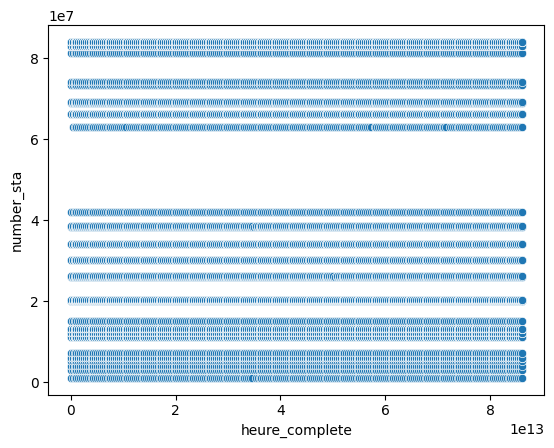

In [ ]:
sns.scatterplot(data = data, x = "heure_complete", y = "number_sta")

In [ ]:
station1 = data[data["number_sta"] == 1089001].reset_index()
station1.describe()

,index,number_sta,lat,lon,date,dd,ff,precip,hu,t,psl,heure,minute,seconde,heure_complete
count,239.000000,239.0,2.390000e+02,239.00,239,239.000000,239.000000,239.0,239.000000,239.000000,239.000000,239.000000,239.000000,239.0,239
mean,55554.564854,1089001.0,4.598000e+01,5.33,2016-01-01 11:57:33.891213312,118.535565,1.751883,0.0,93.631799,278.602301,102320.962343,11.510460,26.937238,0.0,0 days 11:57:33.891213389
min,4.000000,1089001.0,4.598000e+01,5.33,2016-01-01 00:00:00,0.000000,0.000000,0.0,75.000000,276.250000,101590.000000,0.000000,0.000000,0.0,0 days 00:00:00
25%,28601.500000,1089001.0,4.598000e+01,5.33,2016-01-01 05:57:00,20.000000,0.800000,0.0,95.000000,277.150000,101955.000000,5.500000,12.000000,0.0,0 days 05:57:00
50%,55467.000000,1089001.0,4.598000e+01,5.33,2016-01-01 12:00:00,80.000000,1.400000,0.0,97.000000,278.650000,102410.000000,12.000000,24.000000,0.0,0 days 12:00:00
75%,82787.000000,1089001.0,4.598000e+01,5.33,2016-01-01 17:57:00,190.000000,2.200000,0.0,97.000000,279.850000,102690.000000,17.500000,42.000000,0.0,0 days 17:57:00
max,111150.000000,1089001.0,4.598000e+01,5.33,2016-01-01 23:54:00,360.000000,5.800000,0.0,97.000000,282.650000,102800.000000,23.000000,54.000000,0.0,0 days 23:54:00
std,31954.100273,0.0,2.634525e-13,0.00,NaN,113.603827,1.455786,0.0,5.734899,1.474170,403.610172,6.949313,17.278497,0.0,0 days 06:57:20.364345583


In [ ]:
X_station1 = np.array(station1[["dd","ff","precip","hu","t","psl"]])
y_station1 = station1[["heure"]]

### Plotting functions

In [ ]:
def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)

    index = np.arange(len(scores_sorted))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ELBOW plot
    ax1.plot(index, scores_sorted, 'b-o', markersize=4)
    ax1.set_title("Simplicial Volume : Elbow Method")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)

    # GAP plot
    ax2.scatter(index, scores_sorted, c='red', marker='+', s=60)
    ax2.set_title("Simplicial Volume : Gap Method")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_thresholds_zoom(scores):
    # sorted scores
    scores_sorted = np.sort(scores)

    # Zoom on the lowest 40% to better see anomalies
    n_zoom = int(len(scores) * 0.40)
    scores_zoom = scores_sorted[:n_zoom]
    print(scores_zoom)
    index = np.arange(n_zoom)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ELBOW plot
    ax1.plot(index, scores_zoom, 'b-o', markersize=4)
    ax1.set_title("halfspace depth : Elbow method (Zoom 40%)")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)

    # GAP plot
    ax2.scatter(index, scores_zoom, c='red', marker='+', s=60)
    ax2.set_title("halfspace depth : Gap method (Zoom 40%)")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Half-space depth

In [ ]:
model=DepthEucl().load_dataset(X_station1)
depthX=model.halfspace(X_station1,exact=False,NRandom=3000,solver='simplerandom',output_option='lowest_depth')

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores_halfspace = model.halfspace(evaluate_dataset=True, exact=False,NRandom=3000, solver='simplerandom',output_option='lowest_depth')

x value is set to the loaded dataset


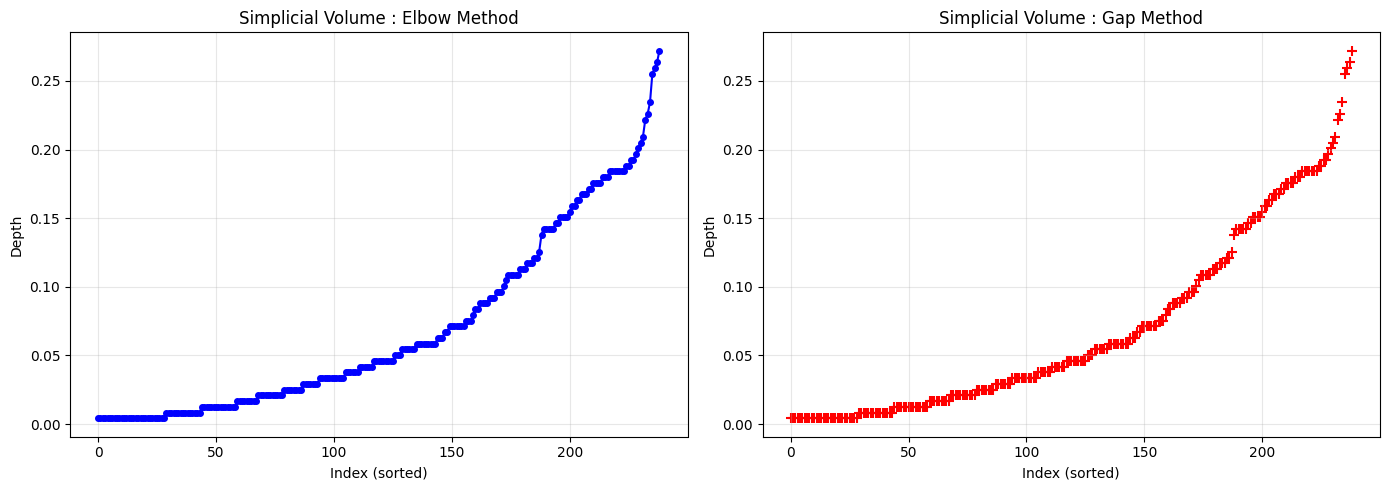

In [ ]:
plot_thresholds(depth_scores_halfspace)

[0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841
 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841
 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841
 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841 0.0041841
 0.0041841 0.0083682 0.0083682 0.0083682 0.0083682 0.0083682 0.0083682
 0.0083682 0.0083682 0.0083682 0.0083682 0.0083682 0.0083682 0.0083682
 0.0083682 0.0083682 0.0125523 0.0125523 0.0125523 0.0125523 0.0125523
 0.0125523 0.0125523 0.0125523 0.0125523 0.0125523 0.0125523 0.0125523
 0.0125523 0.0125523 0.0125523 0.0167364 0.0167364 0.0167364 0.0167364
 0.0167364 0.0167364 0.0167364 0.0167364 0.0167364 0.0209205 0.0209205
 0.0209205 0.0209205 0.0209205 0.0209205 0.0209205 0.0209205 0.0209205
 0.0209205 0.0209205 0.0251046 0.0251046 0.0251046 0.0251046 0.0251046
 0.0251046 0.0251046 0.0251046 0.0292887 0.0292887 0.0292887 0.0292887
 0.0292887 0.0292887 0.0292887 0.0334728]


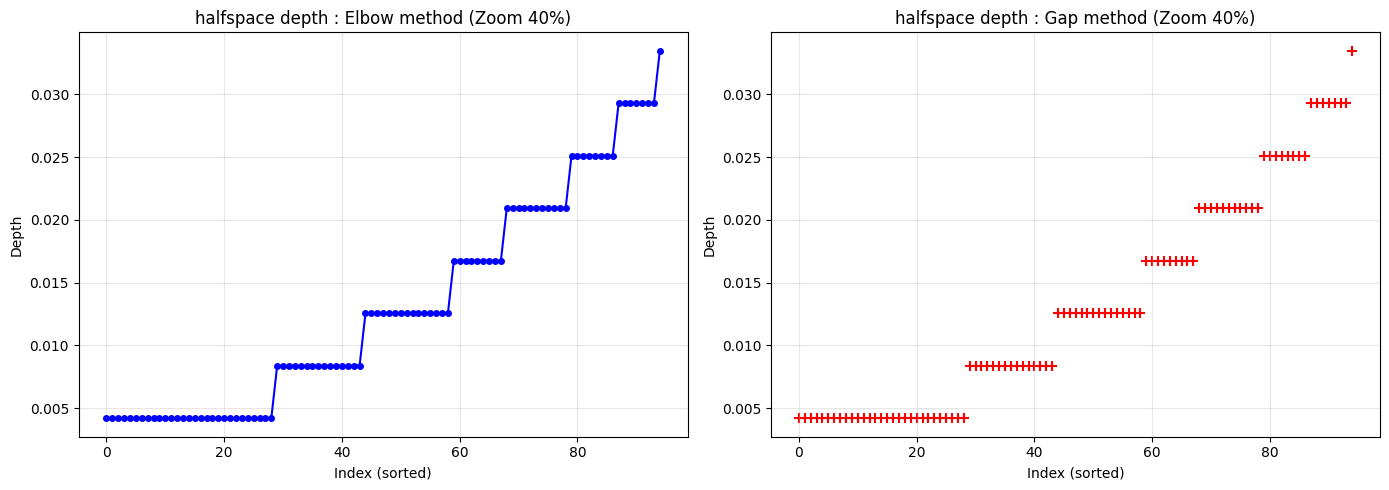

In [ ]:
plot_thresholds_zoom(depth_scores_halfspace)

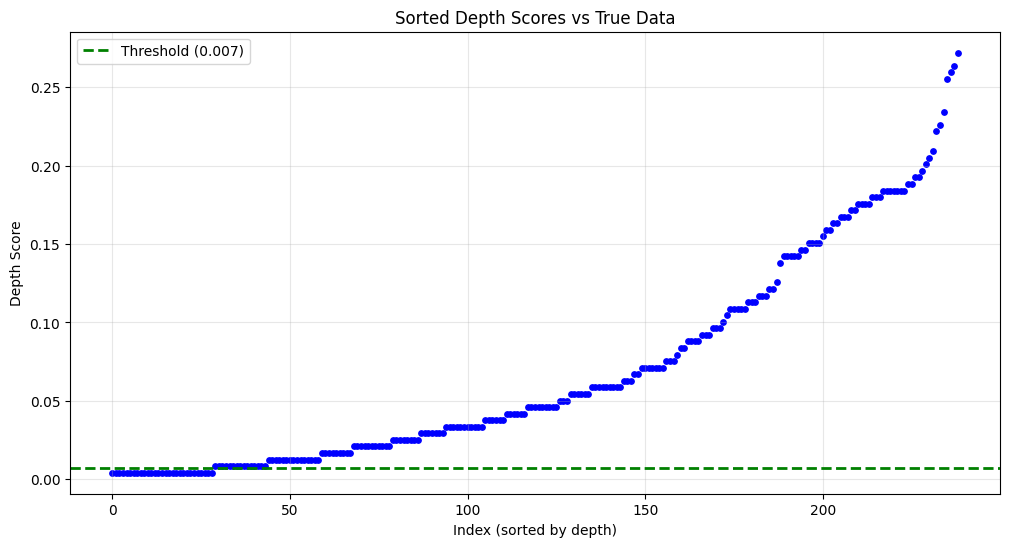

In [ ]:
threshold = 0.007

y_pred = np.where(depth_scores_halfspace < threshold, 1, 0)

sorted_indices = np.argsort(depth_scores_halfspace)
scores_sorted = depth_scores_halfspace[sorted_indices]
y_sorted = y_station1.loc[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y_station1)), scores_sorted,
           c='blue', s=15)
# ax.scatter(np.arange(len(y_station1))[y_sorted["heure"]==1], scores_sorted[y_sorted["heure"]==1],
#            c='red', marker='+', s=80, label=f'Anomalies (4)')

# Add threshold lines
ax.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax.set_title("Sorted Depth Scores vs True Data")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

ValueError: The number of FixedLocator locations (24), usually from a call to set_ticks, does not match the number of labels (2).

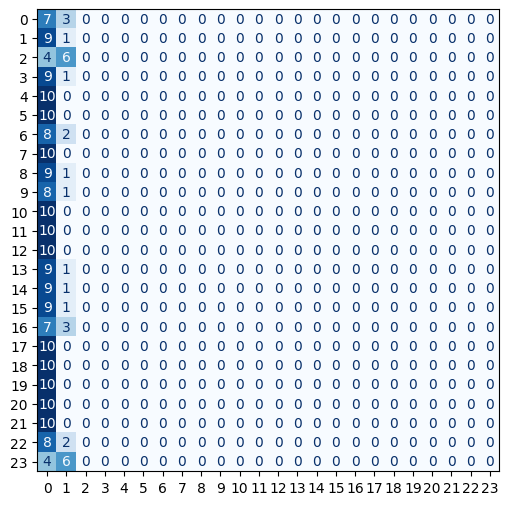

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))


cm_gap = confusion_matrix(y_station1, y_pred)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix : (Threshold = {threshold})")

plt.tight_layout()
plt.show()

### Simplicial depth

x value is set to the loaded dataset


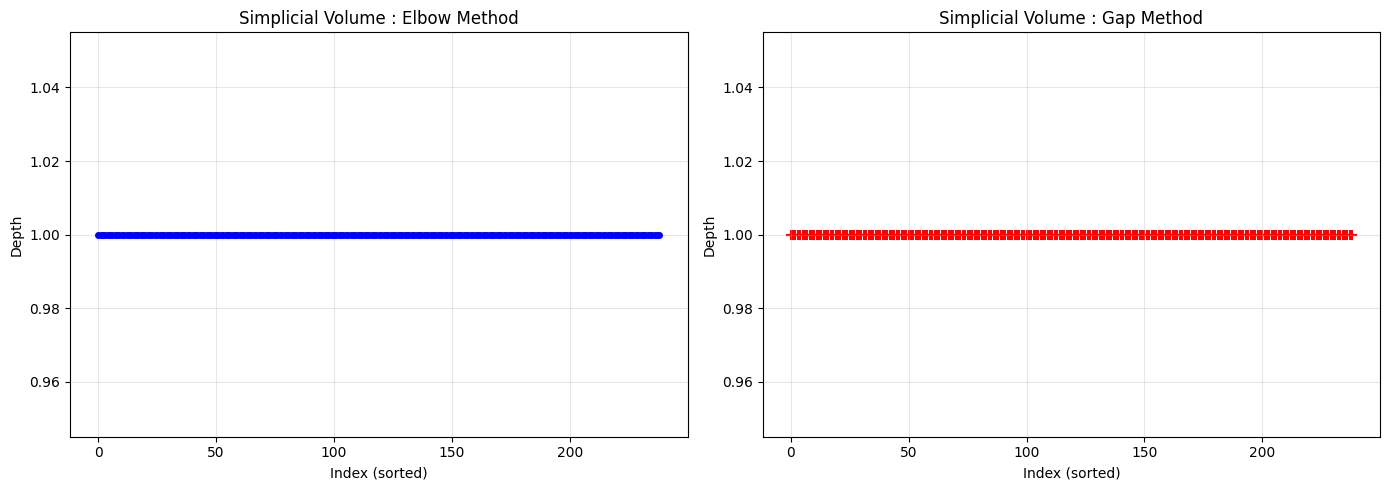

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


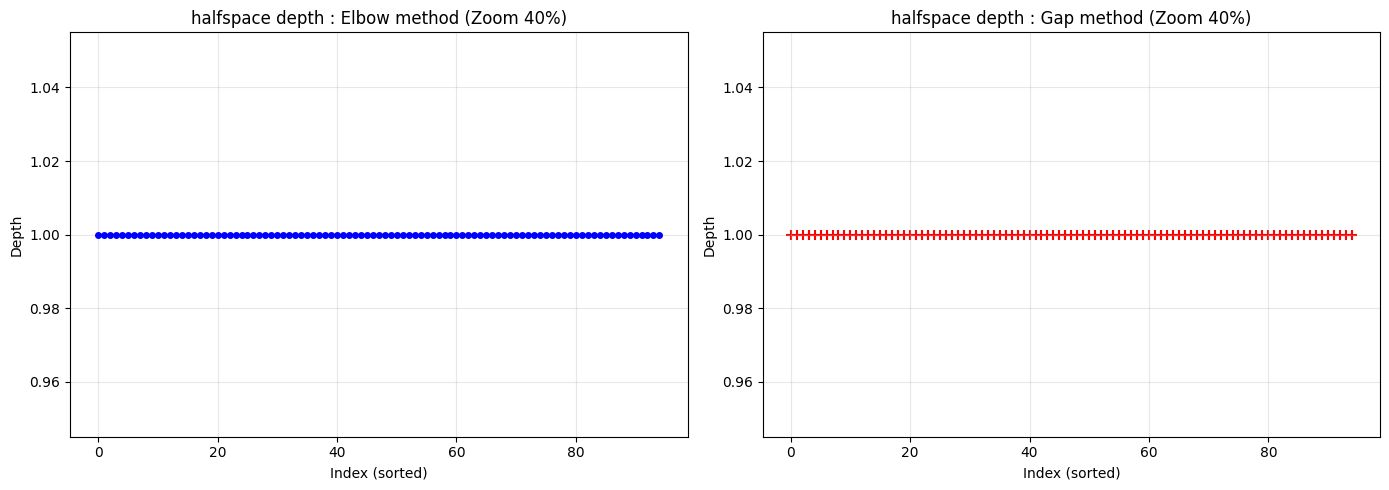

NameError: name 'y' is not defined

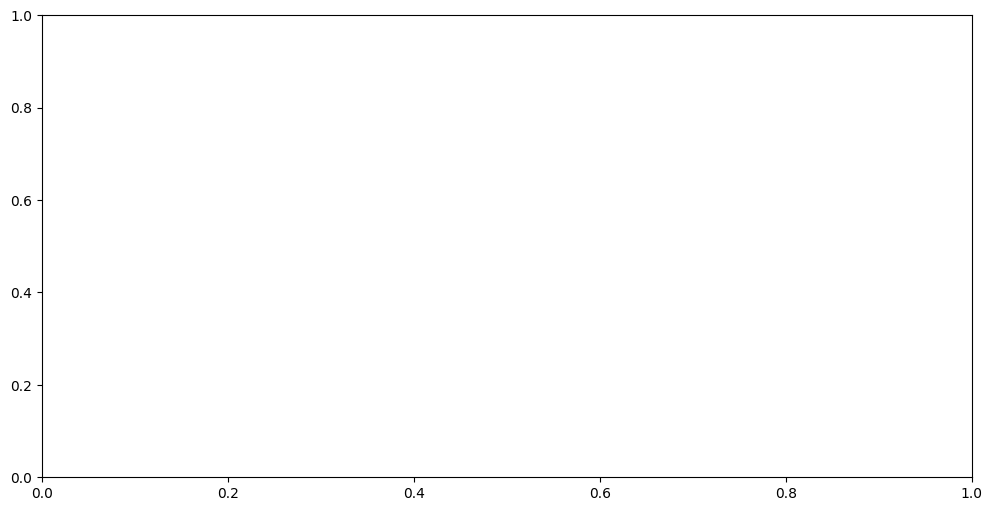

In [ ]:
model=DepthEucl().load_dataset(X_station1)
depth_scores_simplicial_2=model.simplicial(X_station1,exact=False,k=4000,evaluate_dataset=True)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
# depth_scores = model.simplicial(X,evaluate_dataset=True)

plot_thresholds(depth_scores_simplicial_2)

plot_thresholds_zoom(depth_scores_simplicial_2)

threshold = 0.34

y_pred = np.where(depth_scores_simplicial_2 < threshold, 1, 0)

sorted_indices = np.argsort(depth_scores_simplicial_2)
scores_sorted = depth_scores_simplicial_2[sorted_indices]
y_sorted = y_pred[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y))[y_sorted==0], scores_sorted[y_sorted==0],
           c='blue', s=15, label='True Normal (0)')
ax.scatter(np.arange(len(y))[y_sorted==1], scores_sorted[y_sorted==1],
           c='red', marker='+', s=80, label='True anomalies (1)')

# Add threshold lines
ax.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax.set_title("Sorted Depth Scores vs True Data")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



fig, ax = plt.subplots(figsize=(12, 6))


cm_gap = confusion_matrix(y, y_pred)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix : (Threshold = {threshold})")

plt.tight_layout()
plt.show()

### Projection depth

In [ ]:
model=DepthEucl().load_dataset(X)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores_projection_2 = model.projection(X,evaluate_dataset=True,NRandom=10000,output_option="lowest_depth")
def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)

    index = np.arange(len(scores_sorted))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ELBOW plot
    ax1.plot(index, scores_sorted, 'b-o', markersize=4)
    ax1.set_title("projection : Elbow Method")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)

    # GAP plot
    ax2.scatter(index, scores_sorted, c='red', marker='+', s=60)
    ax2.set_title("projection : Gap Method")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_thresholds(depth_scores_projection_2)


def plot_thresholds_zoom(scores):
    # sorted scores
    scores_sorted = np.sort(scores)

    # Zoom on the lowest 20% to better see anomalies
    n_zoom = int(len(scores) * 0.2)
    scores_zoom = scores_sorted[:n_zoom]
    print(scores_zoom)
    index = np.arange(n_zoom)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ELBOW plot
    ax1.plot(index, scores_zoom, 'b-o', markersize=4)
    ax1.set_title("projection depth : Elbow method (Zoom 20%)")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)

    # GAP plot
    ax2.scatter(index, scores_zoom, c='red', marker='+', s=60)
    ax2.set_title("projection depth : Gap method (Zoom 20%)")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_thresholds_zoom(depth_scores_projection_2)

# %% [markdown]
# The threshold is difficult to find with 2 methods we can find a threshold close to the 50 index : threshold : 8e-6

# %%
threshold = 2.5e-06

y_pred = np.where(depth_scores_projection_2 < threshold, 1, 0)

sorted_indices = np.argsort(depth_scores_projection_2)
scores_sorted = depth_scores_projection_2[sorted_indices]
y_sorted = y[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y))[y_sorted==0], scores_sorted[y_sorted==0],
           c='blue', s=15, label='True Normal (0)')
ax.scatter(np.arange(len(y))[y_sorted==1], scores_sorted[y_sorted==1],
           c='red', marker='+', s=80, label='True anomalies (1)')

# Add threshold lines
ax.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax.set_title("Sorted Depth Scores vs True Data")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



fig, ax = plt.subplots(figsize=(12, 6))


cm_gap = confusion_matrix(y, y_pred)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix : (Threshold = {threshold})")

plt.tight_layout()
plt.show()

# %% [markdown]
# we can see that we miss  detect all anomalies but we predict too many anomalies that are normal data.

### ROC Curve

In [ ]:
def plot_roc_curves(dict_scores, y_true):
    plt.figure(figsize=(8, 6))

    for name, scores in dict_scores.items():
        anomaly_scores = -np.array(np.sort(scores))
        fpr, tpr, thresholds = roc_curve(y_true, anomaly_scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})', linestyle='--')

    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FP')
    plt.ylabel('TP')
    plt.title('Comparison of the Depth Functions')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
dict_comparaison = {
   "Halfspace Depth": depth_scores_halfspace_2,
   "Simplicial Depth": depth_scores_simplicial_2,
   "Projection Depth": depth_scores_projection_2,
}

plot_roc_curves(dict_comparaison, y)